# Выявление автоматизированного сбора данных

Нужно оценить каждую cookie по её действиям за сутки. Положительный класс - трафик известных сервисов сбора данных.
Основная метрика: максимальный **Precision среди порогов с Recall >= 70%**.

Решение: очистить события, собрать поведенческие признаки и обучить CatBoost.
Модель выбирается на двух временных блоках. Последние три дня train используются только для финальной проверки.
После неё модель с теми же настройками обучается на всём train и формирует `submission.csv`.

Краткий результат: на финальном отложенном блоке **P@R70 = 0,6512**, у baseline **0,0931**.

Как запустить: установить `requirements.txt`, открыть ноутбук из папки проекта и выполнить все ячейки по порядку. Код подготовки признаков находится в `features.py`, обучение и метрики - в `training.py`. Отдельно пересоздать CSV можно командой `python run.py --verify`.

In [1]:
import os
for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ[variable] = "4"

import sys
import json
import time
import hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.metrics import precision_recall_curve, precision_score, recall_score

from features import load_data, prepare_events, build_features, feature_group
from training import (
    SEED, DEVELOPMENT_FOLDS, HOLDOUT_START, run_experiment, temporal_masks,
    fit_predict, evaluate, best_operating_point, bootstrap_metric,
    model_columns, check_submission,
)

ROOT = Path.cwd()
assert (ROOT / "data/train.csv").exists(), "Откройте ноутбук из папки bot_detection_solution"
RESULTS, FIGURES = ROOT / "results", ROOT / "figures"
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
started = time.perf_counter()
print("Python:", sys.version.split()[0], "Seed:", SEED)

Python: 3.12.14 Seed: 42


## 1. Что находится в файлах

Одна строка train или test - одна cookie с одним окном. Делить строки событий случайно нельзя:
события одной cookie попали бы в обе части.     
Проверим число объектов, даты, баланс классов и пересечение идентификаторов.

In [2]:
train, test, events = load_data(ROOT / "data")
meta = pd.concat([train.drop(columns="target"), test], ignore_index=True)
summary = pd.DataFrame({
    "выборка": ["train", "test"],
    "cookie": [len(train), len(test)],
    "первый день": [train.window_start_ts.min().date(), test.window_start_ts.min().date()],
    "последний день": [train.window_start_ts.max().date(), test.window_start_ts.max().date()],
})
display(summary)
print(f"Ботов в train: {train.target.sum()} из {len(train)}, доля {train.target.mean():.2%}")
print(f"Строк событий: {len(events):,}")
print("Общих cookie у train и test:", len(set(train.cookie_id) & set(test.cookie_id)))
display(events.isna().mean().rename("доля пропусков").to_frame().round(3))

Ботов в train: 899 из 11091, доля 8.11%
Строк событий: 328,905
Общих cookie у train и test: 0


,выборка,cookie,первый день,последний день
0,train,11091,2026-04-06,2026-04-19
1,test,4909,2026-04-20,2026-04-26


,доля пропусков
cookie_id,0.000
event_ts,0.000
eid,0.000
event_name,0.000
platform,0.000
user_agent,0.000
item_id,0.348
item_category,0.100
item_location,0.072
seller_type,0.407


,n,positives,prevalence
window_start_ts,,,
2026-04-06,772,68,0.088083
2026-04-07,797,59,0.074028
2026-04-08,834,70,0.083933
2026-04-09,902,66,0.073171
2026-04-10,912,82,0.089912
2026-04-11,896,79,0.088170
2026-04-12,817,67,0.082007
2026-04-13,843,53,0.062871
2026-04-14,826,70,0.084746


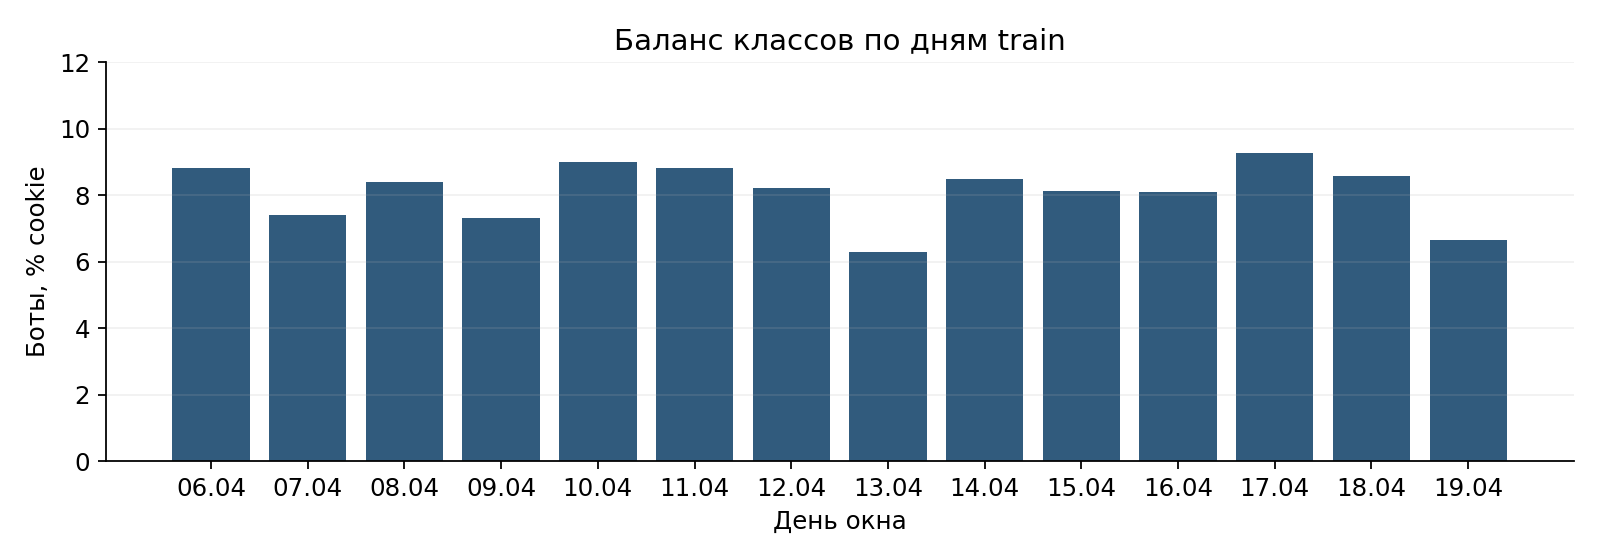

In [3]:
daily = train.groupby("window_start_ts").target.agg(n="size", positives="sum", prevalence="mean")
display(daily)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(daily.index.strftime("%d.%m"), daily.prevalence * 100, color="#315B7D")
ax.set(ylabel="Боты, % cookie", xlabel="День окна", title="Баланс классов по дням train")
ax.set_ylim(0, 12)
ax.grid(axis="y", alpha=.18)
fig.tight_layout()
fig.savefig(FIGURES / "daily_prevalence.png", dpi=160)
plt.close(fig)
display(Image(filename=str(FIGURES / "daily_prevalence.png")))

## 2. Окно, дубликаты и пропуски

Берём только события с `window_start_ts <= event_ts < window_end_ts`.
Затем удаляем полные дубликаты исходных строк. Разные события с одним timestamp сохраняем:
при точности до секунды они вполне могут совпасть по времени.

Оказалось, что 40 779 событий находятся после окончания окна. Среди них - все 7 928 показов капчи.
Использовать капчу в этом наборе как сигнал бота было бы утечкой.
Внутри окна ещё 4 293 полных дубликата. Счётчики исключённых событий в модель не передаются.

Пропуски можно объяснить схемой событий: номер страницы есть у поиска, а координаты курсора доступны не везде.
Поэтому не заполняем исходные координаты или id нулями. Агрегаты строятся по доступным значениям,
доли пропусков считаются отдельно.

In [4]:
clean_events, audit = prepare_events(events, meta)
display(pd.Series(audit, name="строк").to_frame())
print("Капча внутри разрешённого окна:", int(clean_events.event_name.eq("captcha_shown").sum()))
display(clean_events.event_name.value_counts().rename("событий").to_frame())
assert audit["raw_events"] == (audit["unknown_cookie_events"] + audit["before_window"]
    + audit["after_or_at_window_end"] + audit["duplicates_in_window"] + audit["clean_events"])

Капча внутри разрешённого окна: 0


,строк
raw_events,328905
unknown_cookie_events,0
before_window,0
after_or_at_window_end,40779
in_window_before_dedup,288126
duplicates_in_window,4293
clean_events,283833
cookies_without_events,0


,событий
event_name,
item_view,106448
search_results_view,88479
photo_swipe,32570
favorite_add,17012
seller_page_view,15343
contact_phone_show,10145
login,5579
contact_chat_open,5479
contact_message_sent,2778


## 3. Признаки

Главная гипотеза: важны не только объём действий, но и разнообразие объектов, сочетания действий.

| Группа | Что считаем | Зачем |
|---|---|---|
| Действия | Число и доли событий, контакты и фото на просмотр | Отличить просмотр объявлений от последовательного сбора |
| Объекты | Разнообразие объявлений, категорий, городов и запросов, доля самого частого значения, энтропия | Найти узкую специализацию и повторяемость |
| Время | Квантили интервалов, короткие интервалы, логарифмы пауз, пики активности | Описать скорость и регулярность без одного жёсткого порога |
| Сессии | Число сессий, длительность и число действий; разрыв больше 30 минут начинает новую сессию | Отделить ритм работы от длинного простоя |
| Поиск | Глубина выдачи, повтор страниц и переход на следующую страницу того же запроса | Найти систематический обход выдачи |
| Связи действий | Повтор типа события, действия с одним объявлением, сочетание просмотра и фото/контакта одного объявления | Описать связность поведения |
| Курсор | Доля доступных координат, повтор точек, относительный разброс расстояний | Использовать наблюдаемое поведение, не запоминая разрешение экрана |
| Возраст | Логарифм возраста cookie к концу окна | Учесть разницу между новыми и давно существующими cookie |
| Клиент, только для сравнения | Нормализованная платформа и семейство UA | Проверить полезность технических признаков |

`cookie_id`, значения `item_id`, сырые запросы, полные UA, версии браузеров, абсолютные даты и события после окна
не поступают в модель. Категориальные значения используются для подсчёта долей и разнообразия.
Объединение train и test при агрегации безопасно: каждая строка признаков зависит только от своей cookie,
общие частоты и статистики по всему набору не обучаются.

`cv = std / mean`; энтропия выше при более равномерном распределении действий между объектами.
Неопределённая статистика получает `-1`, а нулевой счётчик остаётся нулём.
Например, отсутствие интервала у одного события не равно нулевому интервалу между двумя событиями.
При совпадении времени неоднозначные переходы и перемещения курсора исключаются из последовательных признаков.

In [5]:
feature_started = time.perf_counter()
X = build_features(clean_events, meta)
X_train, X_test = X.loc[train.cookie_id], X.loc[test.cookie_id]
print("Матрица признаков:", X.shape)
print(f"Время построения: {time.perf_counter() - feature_started:.1f} с")
assert X.index.is_unique and np.isfinite(X.to_numpy()).all()
assert X_train.index.tolist() == train.cookie_id.tolist()
assert X_test.index.tolist() == test.cookie_id.tolist()
feature_catalog = pd.DataFrame({"feature": X.columns, "group": [feature_group(c) for c in X.columns]})
display(feature_catalog.groupby("group").size().rename("признаков").to_frame())
display(X_train[["n_events", "item_unique_ratio", "short_gap_cv", "session_count", "search_page_max"]].head())
print("Постоянные на train колонки:", X_train.columns[X_train.nunique().eq(1)].tolist())

Матрица признаков: (16000, 191)
Время построения: 139.7 с
Постоянные на train колонки: ['no_events', 'count_captcha_shown', 'share_captcha_shown', 'platform_nunique', 'platform_unknown_share', 'ua_edge_share', 'ua_other_share']


,признаков
group,
actions,81
age,1
client,22
pointer,7
timing,80


,n_events,item_unique_ratio,short_gap_cv,session_count,search_page_max
cookie_id,,,,,
ck_54a059eb7d3ea68b,7.0,1.000000,0.982273,1.0,6.0
ck_7e4de46eeab82974,41.0,0.593750,0.667706,7.0,8.0
ck_9320229ef6304522,36.0,0.950000,0.927992,7.0,10.0
ck_30ccd25bc1714ed9,21.0,0.555556,0.520972,3.0,2.0
ck_a77c5f05948cdeef,28.0,0.727273,0.799655,4.0,7.0


## 4. Как выбирается модель

В test лежат 20-26 апреля, в train - 6-19 апреля. Повторяем это направление времени.

| Назначение | Обучение | Проверка |
|---|---|---|
| Подбор, блок 1 | 6-12 апреля | 13-14 апреля |
| Подбор, блок 2 | 6-14 апреля | 15-16 апреля |
| Финальная проверка | 6-16 апреля | 17-19 апреля |
| Модель для submission | 6-19 апреля | 20-26 апреля, без меток |

Для выбора сравниваем средний P@R70 по двум первым блокам. Это два повторяющихся во времени эксперимента,
а не случайная кросс-валидация. Для обучения разрешены только окна, которые уже закончились к началу проверки.
Метрика импортируется из `metric.py`. Равные score нельзя разделять,
а выбирать нужно максимум precision по всей допустимой области recall.

В baseline оставляем два признака из ноутбука quickstart: число событий и число уникальных объявлений.
Для честного сравнения он получает ту же очистку событий и seed 42.
Далее сравниваем HistGradientBoosting и CatBoost глубины 4, 6 и 7, добавление признаков,
удаление клиентских признаков, повышение веса положительного класса и усреднение моделей.
Число итераций CatBoost фиксировано: 800 при learning_rate 0,04. Последние три дня не используются
ни для ранней остановки, ни для выбора параметров.

In [6]:
experiment_configs = json.loads((ROOT / "experiment_configs.json").read_text())
ensemble_configs = json.loads((ROOT / "ensemble_configs.json").read_text())
rows, prediction_parts = [], []
for config in experiment_configs:
    fold_result, fold_prediction = run_experiment(X_train, train, config)
    rows.append(fold_result)
    prediction_parts.append(fold_prediction)

wide = pd.concat(prediction_parts).pivot(
    index=["cookie_id", "target", "valid_start"], columns="experiment", values="score"
)
for name, members in ensemble_configs.items():
    prediction = wide[members].mean(axis=1).rename("score").reset_index()
    prediction["experiment"] = name
    prediction_parts.append(prediction)
    rows.append(pd.DataFrame([
        {"experiment": name, "valid_start": start, **evaluate(group.target, group.score)}
        for start, group in prediction.groupby("valid_start")
    ]))

development_results = pd.concat(rows, ignore_index=True)
development_predictions = pd.concat(prediction_parts, ignore_index=True)
development_results.to_csv(RESULTS / "development_results.csv", index=False)
development_predictions.to_csv(RESULTS / "development_predictions.csv", index=False)
comparison = development_results.pivot(index="experiment", columns="valid_start", values="p_at_r70")
comparison["mean_P@R70"] = comparison.mean(axis=1)
comparison["mean_AP"] = development_results.groupby("experiment").average_precision.mean()
display(comparison.sort_values("mean_P@R70", ascending=False).round(4))

quickstart_rf            2026-04-13: P@R70=0.0837; AP=0.2554
quickstart_rf            2026-04-15: P@R70=0.1039; AP=0.2081
hist_full                2026-04-13: P@R70=0.5714; AP=0.7142
hist_full                2026-04-15: P@R70=0.6875; AP=0.7468
cat_original_d4          2026-04-13: P@R70=0.5210; AP=0.7196
cat_original_d4          2026-04-15: P@R70=0.6929; AP=0.7642
cat_original_d6          2026-04-13: P@R70=0.6084; AP=0.7226
cat_original_d6          2026-04-15: P@R70=0.6846; AP=0.7618
cat_original_d7          2026-04-13: P@R70=0.5305; AP=0.7133
cat_original_d7          2026-04-15: P@R70=0.6667; AP=0.7639
cat_original_no_client   2026-04-13: P@R70=0.5472; AP=0.7138
cat_original_no_client   2026-04-15: P@R70=0.6742; AP=0.7577
cat_extended_d6          2026-04-13: P@R70=0.5918; AP=0.7231
cat_extended_d6          2026-04-15: P@R70=0.6567; AP=0.7540
cat_extended_no_client   2026-04-13: P@R70=0.6042; AP=0.7172
cat_extended_no_client   2026-04-15: P@R70=0.6929; AP=0.7551
cat_extended_weight3    

valid_start,2026-04-13,2026-04-15,mean_P@R70,mean_AP
experiment,,,,
cat_extended_no_client,0.6042,0.6929,0.6485,0.7362
cat_original_d6,0.6084,0.6846,0.6465,0.7422
cat_extended_weight3,0.6027,0.6718,0.6372,0.7391
original_3seeds,0.5577,0.7040,0.6308,0.7447
blend_cat_hist,0.5724,0.6875,0.6299,0.7430
hist_full,0.5714,0.6875,0.6295,0.7305
cat_extended_d6,0.5918,0.6567,0.6243,0.7385
behavior_3seeds,0.5669,0.6742,0.6206,0.7391
cat_extended_d4,0.5613,0.6769,0.6191,0.7395


Выбран CatBoost глубины 6 с расширенными поведенческими признаками без прямых признаков платформы и UA:
0,6042 и 0,6929, среднее 0,6485. У модели на исходных признаках с данными клиента среднее 0,6465.
Разница небольшая; считать её доказанным преимуществом было бы неправильно.
Смысл выбора - сопоставимое качество при меньшей зависимости от окружения клиента.

Удаление статистик времени снижает среднюю метрику до 0,4124. Усреднение трёх запусков выбранной модели
даёт 0,6206, поэтому в итоговом решении остаётся одна модель.
Версии UA нормализованы в экспериментальных вариантах; в итоговую модель не входят даже их семейства.
Ни одна настройка ниже не пересматривается по результатам финальной проверки.

{'name': 'cat_extended_no_client', 'kind': 'catboost', 'feature_set': 'no_client', 'depth': 6, 'iterations': 800, 'seed': 42}
Признаков в итоговой модели: 169


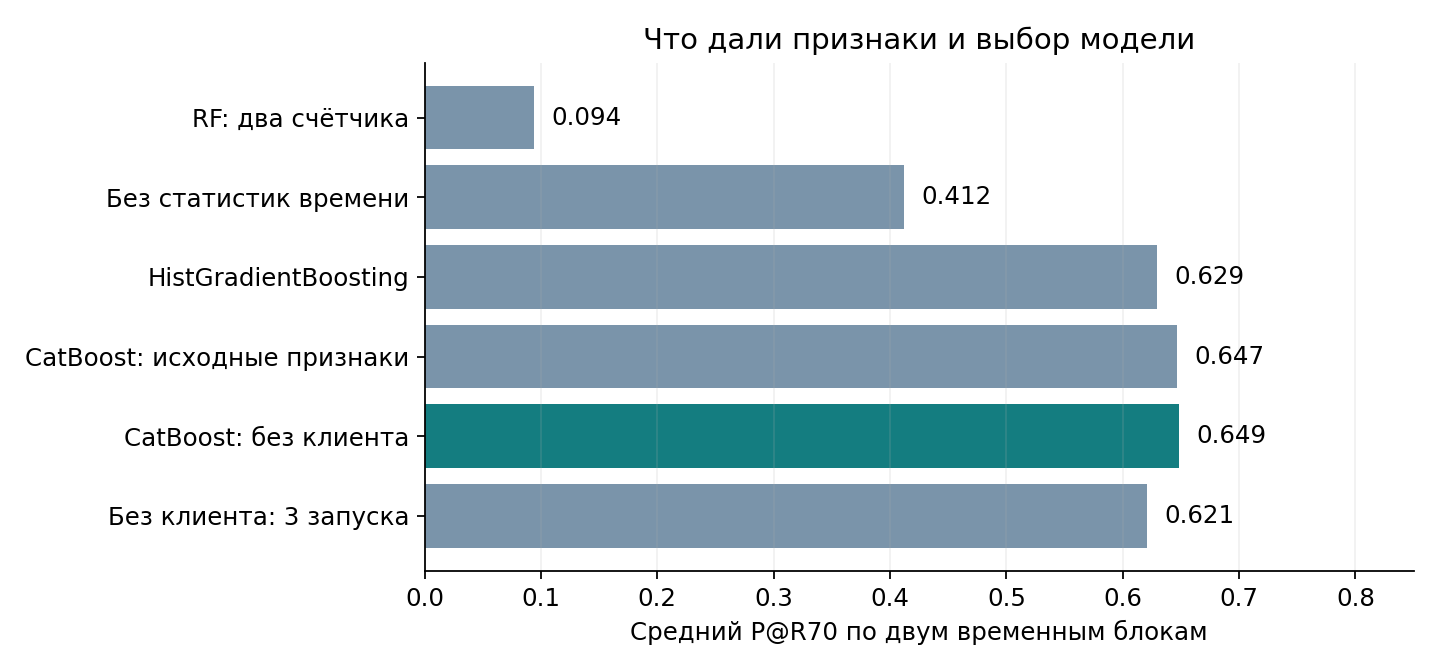

In [7]:
SELECTED_CONFIG = json.loads((ROOT / "model_config.json").read_text())
selected_columns = model_columns(X_train, SELECTED_CONFIG["feature_set"])
print(SELECTED_CONFIG)
print("Признаков в итоговой модели:", len(selected_columns))
assert not any(c.startswith(("ua_", "os_", "platform_")) for c in selected_columns)

show = ["quickstart_rf", "cat_no_timing", "hist_full", "cat_original_d6", "cat_extended_no_client", "behavior_3seeds"]
labels = ["RF: два счётчика", "Без статистик времени", "HistGradientBoosting", "CatBoost: исходные признаки", "CatBoost: без клиента", "Без клиента: 3 запуска"]
values = comparison.loc[show, "mean_P@R70"].to_numpy()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(labels[::-1], values[::-1], color=["#7A94AA", "#147D80", "#7A94AA", "#7A94AA", "#7A94AA", "#7A94AA"])
for i, value in enumerate(values[::-1]):
    ax.text(value + .015, i, f"{value:.3f}", va="center")
ax.set(xlim=(0, .85), xlabel="Средний P@R70 по двум временным блокам", title="Что дали признаки и выбор модели")
ax.grid(axis="x", alpha=.18)
fig.tight_layout()
fig.savefig(FIGURES / "development_comparison.png", dpi=160)
plt.close(fig)
display(Image(filename=str(FIGURES / "development_comparison.png")))

## 5. Финальная проверка: 17-19 апреля

Здесь 1 951 cookie, из них 160 положительных. Обучаем уже выбранную конфигурацию на 6-16 апреля.
В дополнение к основной метрике считаем Average Precision (AP), ROC-AUC и recall при FPR <= 1%.
AP - ступенчатое суммирование precision-recall.

In [8]:
fit_mask, holdout_mask = temporal_masks(train, HOLDOUT_START)
y_holdout = train.loc[holdout_mask, "target"].to_numpy()
p_holdout, holdout_models = fit_predict(
    X_train.loc[fit_mask], train.loc[fit_mask, "target"], X_train.loc[holdout_mask], SELECTED_CONFIG
)
p_baseline, _ = fit_predict(
    X_train.loc[fit_mask], train.loc[fit_mask, "target"], X_train.loc[holdout_mask],
    {"kind": "rf", "feature_set": "baseline"}
)
p_constant = np.full(len(y_holdout), train.loc[fit_mask, "target"].mean())
holdout_metrics = evaluate(y_holdout, p_holdout)
baseline_metrics = evaluate(y_holdout, p_baseline)
display(pd.DataFrame({
    "Константа": evaluate(y_holdout, p_constant),
    "RF: два счётчика": baseline_metrics,
    "Выбранный CatBoost": holdout_metrics,
}).T[["p_at_r70", "average_precision", "roc_auc", "recall_at_fpr01"]].round(4))
point = best_operating_point(y_holdout, p_holdout)
interval = bootstrap_metric(y_holdout, p_holdout)
print("Точка официальной метрики:", point)
print("95% bootstrap-интервал:", interval)

Точка официальной метрики: {'threshold': 0.16760935384902528, 'precision': 0.6511627906976745, 'recall': 0.7, 'tp': 112, 'fp': 60, 'fn': 48, 'tn': 1731}
95% bootstrap-интервал: {'low': 0.4381545269185719, 'high': 0.7891429998572855, 'n_bootstrap': 1000}


,p_at_r70,average_precision,roc_auc,recall_at_fpr01
Константа,0.0820,0.0820,0.5000,0.0000
RF: два счётчика,0.0931,0.1627,0.5749,0.0688
Выбранный CatBoost,0.6512,0.7396,0.9165,0.5500


P@R70 на отложенных днях равен **0,6512**, AP - **0,7396**, ROC-AUC - **0,9165**.
При recall 70% получаем 112 верных срабатываний, 60 ложных и 48 пропущенных ботов.
Если ограничить долю задетых людей одним процентом, recall снижается до 55%.

95% стратифицированный bootstrap-интервал основной метрики примерно **[0,438; 0,789]**.
Он широкий: положительных cookie всего 160, а результат чувствителен к нескольким объектам около порога.
Пересэмплируются уже полученные предсказания внутри классов. Интервал не учитывает переобучение,
связи между cookie одного сервиса и появление новых типов ботов.

Порог из `best_operating_point` выбирается по меткам holdout по правилам задания.
Он нужен для расчёта метрики и разбора ошибок, но не даёт гарантии recall на следующих днях.
В submission порог не отправляется. Ниже отдельно проверим порог, взятый только из двух более ранних блоков.

,значение
threshold_from_development,0.170714
holdout_precision,0.652941
holdout_recall,0.693750


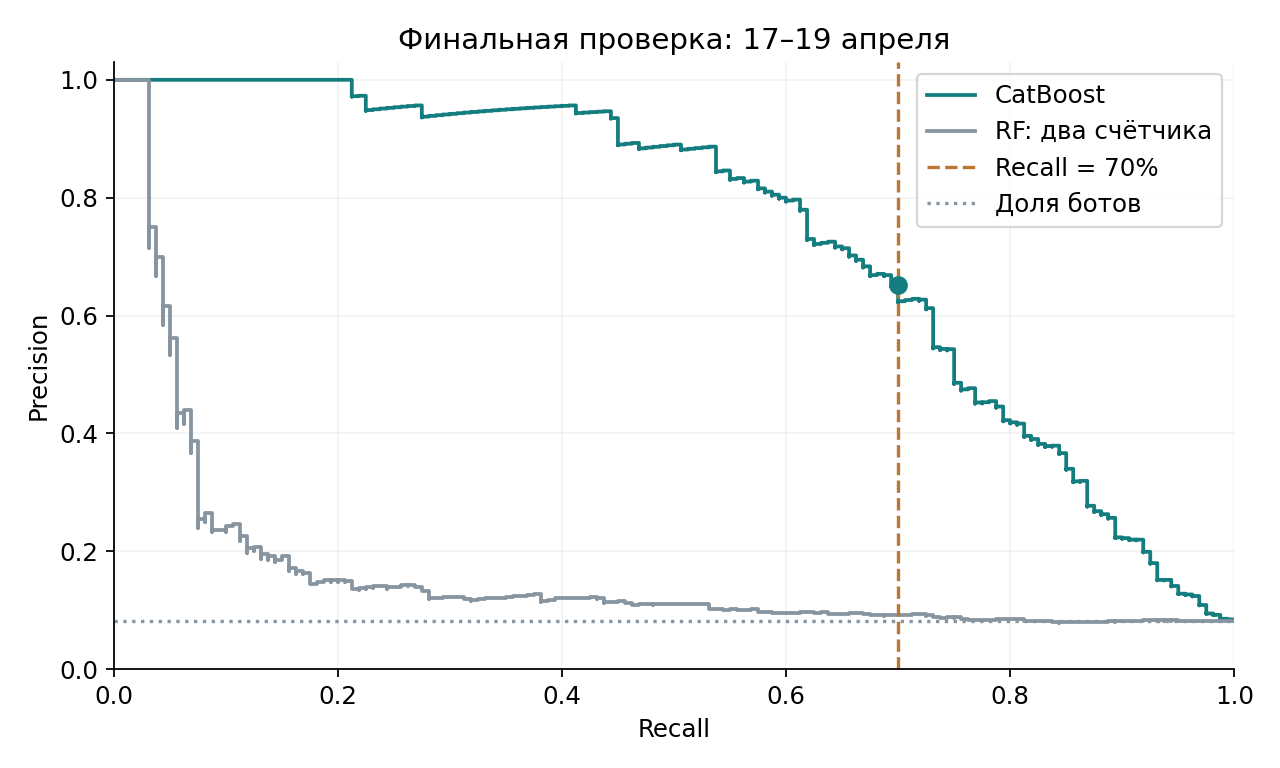

In [9]:
selected_development = development_predictions.loc[
    development_predictions.experiment.eq(SELECTED_CONFIG["name"])
]
earlier_point = best_operating_point(selected_development.target, selected_development.score)
pred_fixed = p_holdout >= earlier_point["threshold"]
fixed_threshold_metrics = {
    "threshold_from_development": earlier_point["threshold"],
    "holdout_precision": float(precision_score(y_holdout, pred_fixed, zero_division=0)),
    "holdout_recall": float(recall_score(y_holdout, pred_fixed)),
}
display(pd.Series(fixed_threshold_metrics).to_frame("значение"))
fig, ax = plt.subplots(figsize=(8, 4.8))
for name, scores, color in [("CatBoost", p_holdout, "#147D80"), ("RF: два счётчика", p_baseline, "#8795A1")]:
    precision, recall, _ = precision_recall_curve(y_holdout, scores)
    ax.step(recall, precision, where="post", label=name, color=color, linewidth=1.7)
ax.axvline(.7, linestyle="--", color="#BB7634", label="Recall = 70%")
ax.axhline(y_holdout.mean(), linestyle=":", color="#8795A1", label="Доля ботов")
ax.scatter([point["recall"]], [point["precision"]], color="#147D80", s=55, zorder=4)
ax.set(xlim=(0, 1), ylim=(0, 1.03), xlabel="Recall", ylabel="Precision", title="Финальная проверка: 17–19 апреля")
ax.legend(loc="upper right")
ax.grid(alpha=.15)
fig.tight_layout()
fig.savefig(FIGURES / "holdout_pr_curve.png", dpi=160)
plt.close(fig)
display(Image(filename=str(FIGURES / "holdout_pr_curve.png")))

## 6. Где модель ошибается

Разбираем ошибки только на размеченном holdout, с уже зафиксированной моделью.
В первую очередь интересны короткие истории: по нескольким событиям трудно отличить человека от аккуратного бота.
Для этой таблицы используем единую точку официальной метрики по всем трём дням.

In [10]:
holdout = pd.DataFrame({
    "cookie_id": train.loc[holdout_mask, "cookie_id"].to_numpy(),
    "date": train.loc[holdout_mask, "window_start_ts"].astype(str).to_numpy(),
    "target": y_holdout, "score": p_holdout, "baseline_score": p_baseline,
    "n_events": X_train.loc[holdout_mask, "n_events"].to_numpy(),
})
holdout["predicted"] = holdout.score.ge(point["threshold"]).astype(int)
holdout.to_csv(RESULTS / "holdout_predictions.csv", index=False)
bins = pd.cut(holdout.n_events, [-1, 5, 15, 30, np.inf], labels=["до 5", "6–15", "16–30", "больше 30"])
slice_rows = []
for label, group in holdout.groupby(bins, observed=False):
    tp = int(((group.target == 1) & (group.predicted == 1)).sum())
    fp = int(((group.target == 0) & (group.predicted == 1)).sum())
    positives = int(group.target.sum())
    slice_rows.append({"событий": str(label), "cookie": len(group), "ботов": positives,
        "найдено ботов": tp, "ложных срабатываний": fp, "recall": tp / positives if positives else np.nan})
error_slices = pd.DataFrame(slice_rows)
display(error_slices.round(3))
error_slices.to_csv(RESULTS / "error_slices.csv", index=False)
daily_scores = pd.DataFrame([
    {"date": day, **evaluate(group.target, group.score)} for day, group in holdout.groupby("date")
])
display(daily_scores[["date", "n", "positives", "p_at_r70", "average_precision"]].round(4))
daily_scores.to_csv(RESULTS / "daily_holdout_metrics.csv", index=False)

,событий,cookie,ботов,найдено ботов,ложных срабатываний,recall
0,до 5,389,14,4,4,0.286
1,6–15,759,45,25,19,0.556
2,16–30,493,57,46,26,0.807
3,больше 30,310,44,37,11,0.841


,date,n,positives,p_at_r70,average_precision
0,2026-04-17,713,66,0.4752,0.7203
1,2026-04-18,606,52,0.6379,0.7141
2,2026-04-19,632,42,0.6667,0.8088


При истории до пяти событий найдено только 4 из 14 ботов. При более чем 30 событиях - 37 из 44.
По отдельным дням P@R70 меняется от 0,475 до 0,667; на таких небольших группах метрика нестабильна.
Дневные значения рассчитываются со своим оптимальным порогом и не обязаны усредняться в общий результат.

Посмотрим, какие признаки использует выбранная модель.

,feature,importance,group
28,item_unique_ratio,3.299,actions
32,category_nunique,3.033,actions
35,category_entropy,2.786,actions
66,short_gap_mean,2.644,timing
40,location_entropy,2.510,actions
79,gap_le_60s_share,2.230,timing
2,cookie_age_log_days,2.120,age
139,extra_gap_log_mean,2.096,timing
33,category_unique_ratio,2.009,actions
34,category_top_share,1.850,actions


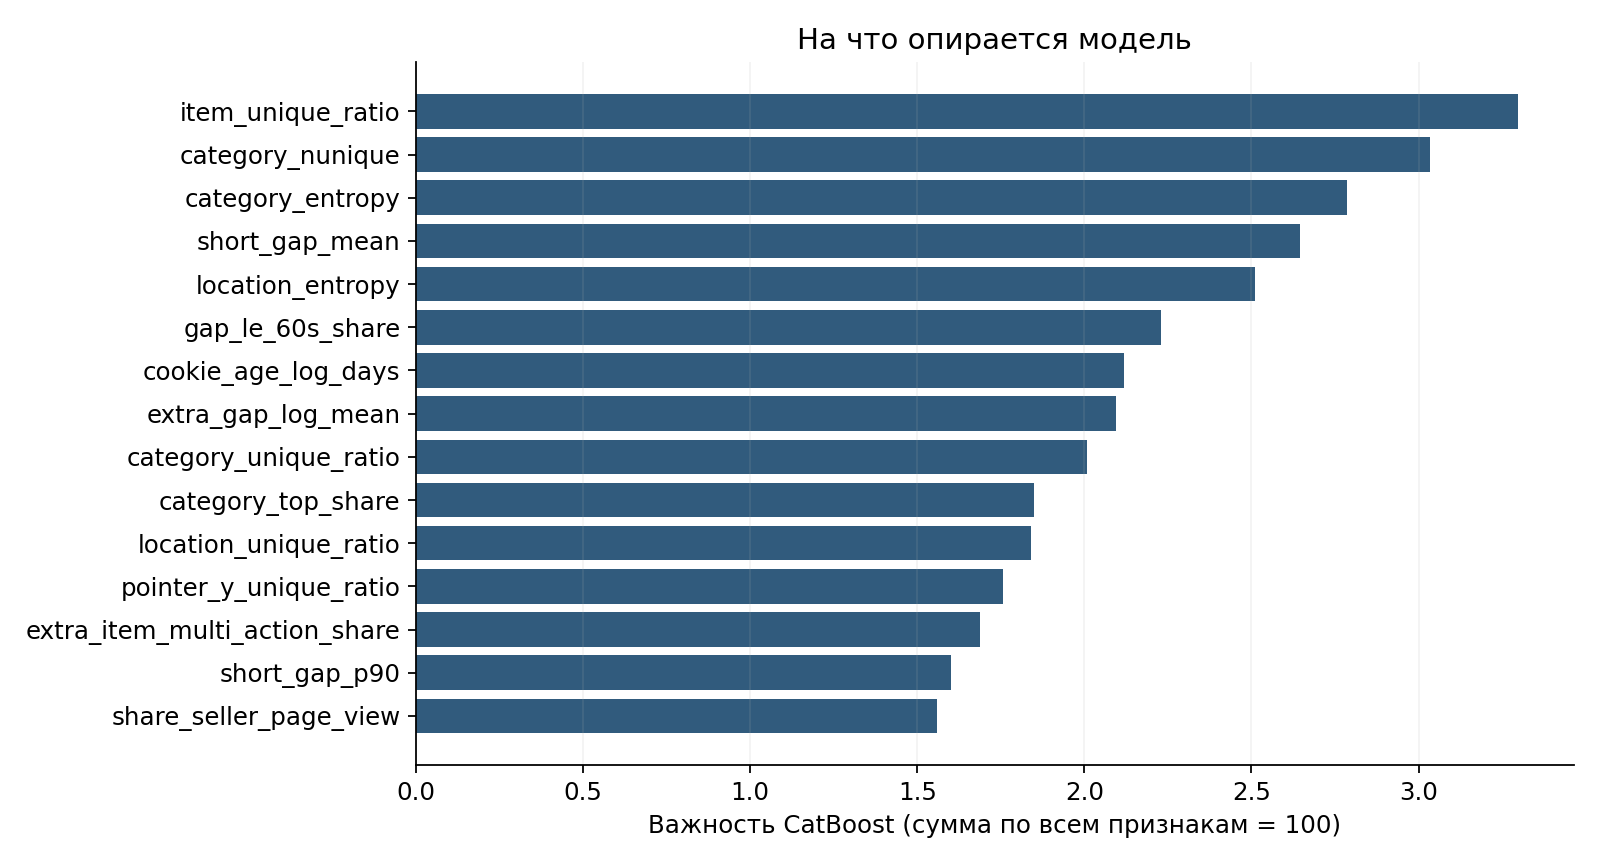

In [11]:
importance = pd.DataFrame({
    "feature": holdout_models[0].feature_names_,
    "importance": holdout_models[0].feature_importances_,
})
importance["group"] = importance.feature.map(feature_group)
importance = importance.sort_values("importance", ascending=False)
importance.to_csv(RESULTS / "feature_importance.csv", index=False)
display(importance.head(15).round(3))
fig, ax = plt.subplots(figsize=(10, 5.4))
top = importance.head(15).iloc[::-1]
ax.barh(top.feature, top.importance, color="#315B7D")
ax.set(xlabel="Важность CatBoost (сумма по всем признакам = 100)", title="На что опирается модель")
ax.grid(axis="x", alpha=.15)
fig.tight_layout()
fig.savefig(FIGURES / "feature_importance.png", dpi=160)
plt.close(fig)
display(Image(filename=str(FIGURES / "feature_importance.png")))

## 7. Обучение на всём train и файл для отправки

Настройки сохраняются. Обучаем одну модель на всех 11 091 размеченных cookie.
На выходе - непрерывные score; порог не применяем. Проверяем точный набор id, порядок строк,
отсутствие пропусков и дубликатов, диапазон от 0 до 1.

In [ ]:
test_scores, final_models = fit_predict(X_train, train.target, X_test, SELECTED_CONFIG)
submission = pd.DataFrame({"cookie_id": test.cookie_id.to_numpy(), "score": test_scores})
check_submission(submission, test)
submission_path = ROOT / "submission.csv"
submission.to_csv(submission_path, index=False, float_format="%.12f", lineterminator="\n")

In [13]:
metrics = {
    "selected_config": SELECTED_CONFIG, "n_features": len(selected_columns), "audit": audit,
    "holdout": holdout_metrics, "baseline_holdout": baseline_metrics,
    "operating_point": point, "bootstrap95": interval,
    "fixed_threshold_diagnostic": fixed_threshold_metrics,
}
(RESULTS / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
from importlib.metadata import version
versions = {package: version(package) for package in ["numpy", "pandas", "scipy", "scikit-learn", "catboost", "matplotlib"]}
print("Версии:", versions)
print(f"Полное выполнение: {time.perf_counter() - started:.1f} с")

Версии: {'numpy': '2.3.5', 'pandas': '2.2.3', 'scipy': '1.17.0', 'scikit-learn': '1.8.0', 'catboost': '1.2.8', 'matplotlib': '3.10.8'}
Полное выполнение: 306.4 с


## Что из этого можно заключить

В этой выборке полезнее всего оказались разнообразие просматриваемых объектов и статистики времени.
Число событий само по себе почти не решает задачу. Добавление всё более сложных моделей не дало устойчивого
прироста на двух временных блоках, поэтому итоговый вариант — один CatBoost.

Ограничения остаются существенными. Короткие истории плохо различимы. Разметка описывает известные сервисы
сбора данных, поэтому полученный score нельзя считать универсальным определителем любого бота.
Отдельного идентификатора источника нет: проверить качество на полностью новом сервисе не получилось.
Также неизвестно, насколько чист отрицательный класс. Score пригоден для ранжирования, но его калибровка
как вероятности отдельно не проверялась.

Для следующей итерации нужны дополнительные размеченные дни и, по возможности, идентификатор источника:
это позволило бы проверить перенос на неизвестные сервисы. Более длинную историю можно добавлять только
при изменении постановки; в текущем решении все поведенческие признаки ограничены выданным суточным окном.

Использованы локальные open-source библиотеки pandas, NumPy, SciPy, scikit-learn, CatBoost и Matplotlib.
Метрика взята из задания.